FINDING THE COLUMNS THAT ARE USUALLY NON-EMPTY IN MOST DELIVERED MEDIA PLANS 

In [77]:
import pandas as pd

SHEET_ID = "1hn2ql2X79pXls3DkCugekPbh5Ar49FVBYaIRSTf7D8Y"
GID = "875183100"

csv_url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"


df = pd.read_csv(csv_url)


print("Shape of DataFrame:", df.shape)
# print(df.head())


percent_missing = df[df["Status"]=="Delivered"].isnull().sum() * 100 / len(df[df["Status"]=="Delivered"])
nan_df = pd.DataFrame({
    "column_name": df[df["Status"]=="Delivered"].columns,
    "percent_nan": percent_missing.values
})


nan_df = nan_df.sort_values(by="percent_nan", ascending=False)

print("\n% of NaN values per column:")
(nan_df)


Shape of DataFrame: (421, 39)

% of NaN values per column:


,column_name,percent_nan
26,Deliverd Views,100.000000
28,Del Complete Views,100.000000
31,Planned CPCV,100.000000
32,Deliverd CPCV,100.000000
27,Pld Complete Views,100.000000
21,Del Freq,100.000000
19,Del Reach 1+,100.000000
36,Paused Date,99.676375
38,Unnamed: 38,99.676375
37,Reason,99.352751


In [78]:
filtered_df = df[
    (df["Status"] == "Delivered") &
    (df["Del Cpm/\nBidvid  cpm"].notna())
]

# Calculate % NaN per column
percent_missing = filtered_df.isnull().sum() * 100 / len(filtered_df)

nan_df = (
    pd.DataFrame({
        "column_name": percent_missing.index,
        "percent_nan": percent_missing.values
    })
    .sort_values(by="percent_nan", ascending=False)
)

nan_df

,column_name,percent_nan
36,Paused Date,100.000000
37,Reason,100.000000
27,Pld Complete Views,100.000000
29,Planned CPV,100.000000
30,Del Cpv,100.000000
21,Del Freq,100.000000
19,Del Reach 1+,100.000000
31,Planned CPCV,100.000000
32,Deliverd CPCV,100.000000
25,Planned views,100.000000


TOTAL NUMBER OF DELIVERED COLUMNS 

In [79]:
len(df[df["Status"]=="Delivered"])

309

In [80]:
df=df[
    (df["Status"] == "Delivered") &
    (df["Del Cpm/\nBidvid  cpm"].notna())
]

In [81]:
cpm_col = "Del Cpm/\nBidvid  cpm"

df[cpm_col] = (
    df[cpm_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.strip()
)

df[cpm_col] = pd.to_numeric(df[cpm_col], errors="coerce")

In [82]:
# Columns to keep (based on NaN analysis & relevance)
cols_to_keep = [
    "Mobile / CTV",
    "Device",
    "Start Date",
    "End Date",
    "TG",
    "Planned Impressions",
    "Planned Reach 1+",
    "Planned Freq",
    "Planned Budget",
    "Markets",
    "Del Cpm/\nBidvid  cpm",
    "Planned CPM - Non Bidvid"
]

# Keep only these columns (ignore missing ones safely)
df = df.loc[:, df.columns.intersection(cols_to_keep)]

UNDERSTANDING EACH COLUMN

### Categorical columns and their types

We observe here that there is no normalization in the names of these categorical variables and affecting model's accuracy 

Solution:

i)  Defining a cannonical taxanomy
ii) Using Regex to categorize 
iii) Rule-Based Normalization 

**NOTE: For these we require the exact name of these limited categories for Devices,TG**

In [83]:
df["Device"].value_counts()

Device
YT NSK                                66
YT CTV                                25
Non Skipable                           9
Non-skippable                          8
YT CTV non skip                        5
Non-skip                               4
Non-Skip                               3
Non-skippable + Bumper + YT shorts     2
YT Mobile (VAS)                        2
YT NSK (All Devices)                   2
Bumper + Shorts                        2
All                                    1
YT Shorts                              1
YT NSK/Reach                           1
Name: count, dtype: int64

has_nsk       ∈ {0,1,NaN}

has_sk        ∈ {0,1,NaN}

has_bumper    ∈ {0,1,NaN}

has_shorts    ∈ {0,1,NaN}

format_unknown ∈ {0,1}

In [84]:
import pandas as pd
import numpy as np
import re

def parse_yt_format(value):
    """
    Parses YouTube format information from the Device column
    and returns multi-hot format flags.
    """

    # Default output
    result = {
        "has_nsk": np.nan,
        "has_sk": np.nan,
        "has_bumper": np.nan,
        "has_shorts": np.nan,
        "format_unknown": 0
    }

    # Handle NaN
    if pd.isna(value):
        result["format_unknown"] = 1
        return result

    v = value.lower().strip()

    # Pure device / placement only → unknown format
    device_only_patterns = [
        "yt ctv",
        "youtube ctv",
        "mobile",
        "smartphone",
        "vas",
        "desktop",
        "all devices",
        "all"
    ]

    if any(p in v for p in device_only_patterns) and not any(
        x in v for x in ["skip", "nsk", "bumper", "short"]
    ):
        result["format_unknown"] = 1
        return result

    # Initialize known formats as 0
    result["has_nsk"] = 0
    result["has_sk"] = 0
    result["has_bumper"] = 0
    result["has_shorts"] = 0

    # NSK (Non-skippable)
    if re.search(r"\bnsk\b|non[-\s]?skip", v):
        result["has_nsk"] = 1

    # Skippable
    if re.search(r"\bskip\b|skippable", v) and not re.search(r"non[-\s]?skip", v):
        result["has_sk"] = 1

    # Bumper
    if "bumper" in v:
        result["has_bumper"] = 1

    # Shorts
    if "short" in v:
        result["has_shorts"] = 1

    # Handle "All" explicitly meaning all formats
    if v == "all":
        result["has_nsk"] = 1
        result["has_sk"] = 1
        result["has_bumper"] = 1
        result["has_shorts"] = 1

    # If no format detected → unknown
    if (
        result["has_nsk"] == 0 and
        result["has_sk"] == 0 and
        result["has_bumper"] == 0 and
        result["has_shorts"] == 0
    ):
        result["format_unknown"] = 1
        result["has_nsk"] = np.nan
        result["has_sk"] = np.nan
        result["has_bumper"] = np.nan
        result["has_shorts"] = np.nan

    return result

In [85]:
format_df = df["Device"].apply(parse_yt_format).apply(pd.Series)

df = pd.concat([df, format_df], axis=1)

In [86]:
df["format_unknown"].value_counts()

format_unknown
0.0    103
1.0     45
Name: count, dtype: int64

In [87]:
df[
    (df["has_bumper"] == 1) &
    (df["has_shorts"] == 1)
][["Device", "has_nsk", "has_sk", "has_bumper", "has_shorts"]]

,Device,has_nsk,has_sk,has_bumper,has_shorts
313,Bumper + Shorts,0.0,0.0,1.0,1.0
314,Bumper + Shorts,0.0,0.0,1.0,1.0
315,Non-skippable + Bumper + YT shorts,1.0,0.0,1.0,1.0
316,Non-skippable + Bumper + YT shorts,1.0,0.0,1.0,1.0


In [88]:
df.groupby("has_nsk")["Del Cpm/\nBidvid  cpm"].mean()

has_nsk
0.0    21.840
1.0    91.091
Name: Del Cpm/\nBidvid  cpm, dtype: float64

In [89]:
df["format_unknown"].mean()

np.float64(0.30405405405405406)

In [90]:
df.loc[df["format_unknown"] == 1, "Device"].value_counts()

Device
YT CTV             25
YT Mobile (VAS)     2
All                 1
Name: count, dtype: int64

**Different genders**

is_male ;
is_female ;
is_mixed_gender

**Different age groups**

age_min;
age_max;

Raw TG string
     ↓
Regex extraction
     ↓
Structured attributes
     ↓
Binary + numeric features
     ↓
Tree model (XGBoost / LGBM)

In [91]:
df["TG"].value_counts()

TG
F 25-44 NCCS AB                                         57
F 25- 44 + HHI Top 50%                                  12
F 25 - 44                                                9
TG: F 25-44 + HHI 50%                                    7
F 18-44 NCCS AB                                          6
Female 25 - 45                                           5
MF 18-24 NCCS A                                          5
MF 25-34 NCCS A                                          4
HHI Top 21% to 50%                                       4
F 18-44 NCCS ABC                                         4
F 25-44 ABC                                              4
F25-44 AB                                                4
F18-34 AB                                                4
Demo (F 25-44) | Geo | NCCS AB                           3
Female 25 - 45                                           3
25-44, M/F, P1 + P2, Affinities & Inmarket audiences     2
F25-44                                               

In [92]:
def parse_tg(value):
    result = {
        "age_min": np.nan,
        "age_max": np.nan,
        "is_male": np.nan,
        "is_female": np.nan,
        "is_both_genders": np.nan
    }

    if pd.isna(value):
        return result

    v = value.lower()

    # --------------------
    # AGE PARSING
    # --------------------
    age_match = re.search(r"(\d{2})\s*[-–]\s*(\d{2})", v)
    if age_match:
        result["age_min"] = int(age_match.group(1))
        result["age_max"] = int(age_match.group(2))

    # --------------------
    # GENDER PARSING
    # --------------------
    # Initialize gender flags as 0
    result["is_male"] = 0
    result["is_female"] = 0
    result["is_both_genders"] = 0

    # Mixed gender
    if re.search(r"\bmf\b|m/f|male\s*&\s*female", v):
        result["is_male"] = 1
        result["is_female"] = 1
        result["is_both_genders"] = 1

    else:
        # Female
        if re.search(r"\bf\b|female", v):
            result["is_female"] = 1

        # Male
        if re.search(r"\bm\b|male", v):
            result["is_male"] = 1

    # If no gender info detected → revert to NaN
    if (
        result["is_male"] == 0 and
        result["is_female"] == 0 and
        result["is_both_genders"] == 0
    ):
        result["is_male"] = np.nan
        result["is_female"] = np.nan
        result["is_both_genders"] = np.nan

    return result

In [93]:
tg_df = df["TG"].apply(parse_tg).apply(pd.Series)

df = pd.concat([df, tg_df], axis=1)

In [94]:
df[["TG", "age_min", "age_max"]].head(10)

,TG,age_min,age_max
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
42,F 25-44 NCCS AB,25.0,44.0
43,F 25-44 NCCS AB,25.0,44.0
44,F 25-44 NCCS AB,25.0,44.0
45,F 25-44 NCCS AB,25.0,44.0


In [95]:
df["format_unknown"].value_counts()

format_unknown
0.0    103
1.0     45
Name: count, dtype: int64

In [96]:
df[["is_male", "is_female", "is_both_genders"]].sum()

is_male             19.0
is_female          123.0
is_both_genders     11.0
dtype: float64

In [97]:
df[df["is_both_genders"] == 1][["TG", "age_min", "age_max"]]

,TG,age_min,age_max
63,MF 25-34 NCCS A,25.0,34.0
64,MF 25-34 NCCS A,25.0,34.0
65,MF 25-34 NCCS A,25.0,34.0
66,MF 25-34 NCCS A,25.0,34.0
67,MF 18-24 NCCS A,18.0,24.0
68,MF 18-24 NCCS A,18.0,24.0
69,MF 18-24 NCCS A,18.0,24.0
70,MF 18-24 NCCS A,18.0,24.0
71,MF 18-24 NCCS A,18.0,24.0
77,"25-44, M/F, P1 + P2, Affinities & Inmarket aud...",25.0,44.0


In [98]:
def extract_purchasing_power(value):
    result = {
        "pp_high": np.nan,
        "pp_medium": np.nan,
        "pp_low": np.nan,
        "pp_unknown": 0
    }

    if pd.isna(value):
        result["pp_unknown"] = 1
        return result

    v = value.lower()

    # Initialize
    result["pp_high"] = 0
    result["pp_medium"] = 0
    result["pp_low"] = 0

    # ------------------
    # HIGH purchasing power
    # ------------------
    if (
        re.search(r"nccs\s*a\b|nccs\s*ab\b", v)
        or re.search(r"\bab\b", v)          # implicit NCCS AB
        or re.search(r"hhi.*top\s*20", v)
        or re.search(r"\bp1\b|\bp2\b", v)
        or "affinit" in v
        or "inmarket" in v
    ):
        result["pp_high"] = 1

    # ------------------
    # MEDIUM purchasing power
    # ------------------
    if (
        re.search(r"nccs\s*abc\b", v)
        or re.search(r"\babc\b|\babcde\b", v)  # implicit NCCS ABC/ABCDE
        or ("hhi" in v and result["pp_high"] == 0)
        or "all" in v
    ):
        result["pp_medium"] = 1

    # ------------------
    # LOW purchasing power
    # ------------------
    if "rural" in v:
        result["pp_low"] = 1

    # ------------------
    # UNKNOWN
    # ------------------
    if (
        result["pp_high"] == 0
        and result["pp_medium"] == 0
        and result["pp_low"] == 0
    ):
        result["pp_high"] = np.nan
        result["pp_medium"] = np.nan
        result["pp_low"] = np.nan
        result["pp_unknown"] = 1

    return result

In [99]:
pp_df = df["TG"].apply(extract_purchasing_power).apply(pd.Series)
df = pd.concat([df, pp_df], axis=1)

In [100]:
df.loc[df["pp_unknown"] == 1, "TG"].value_counts()

TG
F 25 - 44          9
Female 25 - 45     5
Female 25 - 45     3
F25-44             2
Name: count, dtype: int64

**For Markets**

Use Rule based normalization using Geo-code dataset provided by DV360

In [101]:
df["Markets"]

0          Lucknow
1         Kalcutta
2          Lucknow
3         Kalcutta
4        Delhi NCR
          ...     
324      Delhi NCR
326          Delhi
327    Maharashtra
328      Karnataka
330         UP+UTT
Name: Markets, Length: 148, dtype: object

In [102]:
import pandas as pd
import numpy as np
import re
from difflib import SequenceMatcher

# =========================================================
# 1. Load geo reference (INDIA ONLY, EXCLUDE COUNTRY)
# =========================================================
geo = pd.read_csv(
    "/home/adwitb/Documents/BIdVIdBenchmark/cpm_predictor/data/geotargets-2025-10-29.csv"
)
geo.columns = geo.columns.str.lower()

# Restrict to India
geo = geo[geo["country code"] == "IN"].copy()

# Exclude country-level (India itself)
geo = geo[geo["canonical name"].str.lower() != "india"]

# Split into cities and states
cities = geo[geo["parent id"].notna()].copy()
states = geo[geo["parent id"].isna()].copy()

# Drop rows with missing names
cities = cities[cities["name"].notna()].copy()
states = states[states["name"].notna()].copy()

# Normalize names
cities["name_norm"] = cities["name"].str.lower().str.strip()
states["name_norm"] = states["name"].str.lower().str.strip()

# 🔑 FIX: extract FIRST segment of canonical name
# "West Bengal, India" -> "west bengal"
states["canonical_norm"] = (
    states["canonical name"]
    .str.lower()
    .str.split(",")
    .str[0]
    .str.strip()
)

# =========================================================
# 2. Lookup dictionaries
# =========================================================
city_lookup = {
    row["name_norm"]: (row["criteria id"], row["parent id"])
    for _, row in cities.iterrows()
}

state_lookup = {
    row["name_norm"]: row["criteria id"]
    for _, row in states.iterrows()
}

canonical_state_map = {
    row["canonical_norm"]: row["criteria id"]
    for _, row in states.iterrows()
}

# =========================================================
# 3. Explicit city aliases (legacy spellings)
# =========================================================
CITY_ALIASES = {
    "kalcutta": "kolkata",
    "orissa": "odisha",
}

# =========================================================
# 4. HARDCODED STATE IDS (AUTHORITATIVE)
# =========================================================
HARDCODE_MARKETS_IDS = {
    "up": [20471],
    "uttarpradesh": [20471],

    "wb": [20472],
    "westbengal": [20472],

    "mah": [20473],

    "mpcg": [20464, 21334],        # MP + Chhattisgarh
    "bih+jk": [20455, 21336],      # Bihar + Jharkhand
    "bih + jk": [20455, 21336],

    "aptl": [20453],               # AP (+ Telangana below)
    "ap+tl": [20453],

    "up+utt": [20471, 2356],       # UP + Uttarakhand
}

# =========================================================
# 5. Helpers
# =========================================================
def tokenize(text):
    return set(
        re.sub(r"[^a-z0-9+ ]", " ", text.lower()).split()
    )

def fuzzy_match_state(normalized_text, threshold=0.9):
    best_score = 0
    best_state_id = None

    for canon_name, state_id in canonical_state_map.items():
        score = SequenceMatcher(None, normalized_text, canon_name).ratio()
        if score > best_score:
            best_score = score
            best_state_id = state_id

    if best_score >= threshold:
        return best_state_id

    return None

# =========================================================
# 6. Core normalization function
# =========================================================
def normalize_market(value):
    result = {
        "geo_state_ids": [],
        "geo_city_ids": [],
        "geo_unknown": 0
    }

    if pd.isna(value):
        result["geo_unknown"] = 1
        return result

    v = value.lower()

    # Ignore commentary / planning text
    if any(x in v for x in ["refer", "saving", "billing", "opting out"]):
        result["geo_unknown"] = 1
        return result

    # -----------------------------
    # HARDCODED OVERRIDE (TOP PRIORITY)
    # -----------------------------
    v_norm = v.replace(" ", "").lower()
    if v_norm in HARDCODE_MARKETS_IDS:
        state_ids = set(HARDCODE_MARKETS_IDS[v_norm])

        # Add Telangana dynamically if present
        if v_norm in {"aptl", "ap+tl"}:
            telangana_id = state_lookup.get("telangana")
            if telangana_id:
                state_ids.add(telangana_id)

        result["geo_state_ids"] = list(state_ids)
        result["geo_city_ids"] = []
        result["geo_unknown"] = 0
        return result

    tokens = tokenize(v)
    tokens.add("".join(tokens))

    minus_mode = "minus" in tokens

    city_ids = set()
    state_ids = set()

    # -----------------------------
    # City detection
    # -----------------------------
    for name, (cid, sid) in city_lookup.items():
        if name in v:
            city_ids.add(cid)
            state_ids.add(sid)

    # City aliases
    for alias, canonical in CITY_ALIASES.items():
        if alias in v and canonical in city_lookup:
            cid, sid = city_lookup[canonical]
            city_ids.add(cid)
            state_ids.add(sid)

    # -----------------------------
    # Exact state detection
    # -----------------------------
    for token in tokens:
        if token in state_lookup:
            state_ids.add(state_lookup[token])

    # -----------------------------
    # Minus-city logic
    # -----------------------------
    if minus_mode and state_ids:
        expanded_cities = set(
            cities[cities["parent id"].isin(state_ids)]["criteria id"]
        )
        city_ids = expanded_cities - city_ids

    # -----------------------------
    # FUZZY MATCH FALLBACK (CANONICAL NAME)
    # -----------------------------
    if not state_ids and not city_ids:
        fuzzy_text = re.sub(r"[^a-z ]", " ", v)
        fuzzy_text = re.sub(r"\s+", " ", fuzzy_text).strip()

        state_id = fuzzy_match_state(fuzzy_text)
        if state_id:
            result["geo_state_ids"] = [state_id]
            result["geo_city_ids"] = []
            result["geo_unknown"] = 0
            return result

    # -----------------------------
    # Finalize
    # -----------------------------
    result["geo_state_ids"] = list(state_ids)
    result["geo_city_ids"] = list(city_ids)

    if not result["geo_state_ids"] and not result["geo_city_ids"]:
        result["geo_unknown"] = 1

    return result

# =========================================================
# 7. Apply to dataframe
# =========================================================
market_features = df["Markets"].apply(normalize_market).apply(pd.Series)
df = pd.concat([df, market_features], axis=1)

In [103]:
cities["name_norm"].isna().sum()   # should be 0
states["name_norm"].isna().sum()   # should be 0

np.int64(0)

In [104]:
df[["Markets", "geo_state_ids", "geo_city_ids", "geo_unknown"]].head()

,Markets,geo_state_ids,geo_city_ids,geo_unknown
0,Lucknow,[20471.0],[9182923],0
1,Kalcutta,[20472.0],[9198114],0
2,Lucknow,[20471.0],[9182923],0
3,Kalcutta,[20472.0],[9198114],0
4,Delhi NCR,[20456.0],[9075215],0


In [105]:
df["geo_city_ids"].unique

<bound method Series.unique of 0      [9182923]
1      [9198114]
2      [9182923]
3      [9198114]
4      [9075215]
         ...    
324    [9075215]
326    [9075215]
327      [20462]
328      [20460]
330           []
Name: geo_city_ids, Length: 148, dtype: object>

In [106]:
df.head()

,Device,TG,Mobile / CTV,Start Date,End Date,Markets,Planned Reach 1+,Planned Freq,Planned Budget,Planned Impressions,...,is_male,is_female,is_both_genders,pp_high,pp_medium,pp_low,pp_unknown,geo_state_ids,geo_city_ids,geo_unknown
0,All,NaN,Mobile,"July 2nd, 2025","July 22nd, 2025",Lucknow,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,[20471.0],[9182923],0
1,NaN,NaN,Mobile,"July 2nd, 2025","July 22nd, 2025",Kalcutta,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,[20472.0],[9198114],0
2,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Lucknow,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,[20471.0],[9182923],0
3,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Kalcutta,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,[20472.0],[9198114],0
4,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Delhi NCR,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,[20456.0],[9075215],0


In [107]:
df.loc[df["geo_unknown"] == 1, "Markets"].value_counts()

Markets
Please refer to Aditya Birla LI media plan    2
Name: count, dtype: int64

**For start date and end date**

This has been taken care of using Regex 

Two derived columns are used for this:
i) Duration of campaign (Should be considered with Number of days or months ? )
ii) Month Range

Month range is currently on the basis of campaign start and end dates : 
i.e. for a Jul-Sep and Jul-Oct are two different categories but also have an overlap as Jul-Sep is a subset of Jul-Oct and our model considers them as two different categories 
For this the Solution : 

a) is_Jul , is_Aug , is_Sep ... multiple one hot encoding 
b) as months are cyclical and not linear we need sin_start_month and cos_start_month (Cyclical Encoding)

In [108]:
df["Start Date"].value_counts()

Start Date
1-10-2025         30
25-07-2025        18
15-10-2025        16
1-11-2025         10
31-07-2025         9
8-10-2025          7
27-10-2025         7
27-9-2025          6
3-11-2025          6
July 2nd, 2025     5
28-8-2025          5
16-09-2025         5
17-09-2025         4
26-9-2025          3
18-8-2025          2
01-09-2025         2
30-07-2025         1
17-10-2025         1
Name: count, dtype: int64

In [109]:

# =========================================
# 1. Date cleaning helper
# =========================================
def clean_date_string(x):
    if pd.isna(x):
        return x
    x = str(x).lower()
    # remove ordinal suffixes: 1st, 2nd, 3rd, 4th
    x = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', x)
    return x

# =========================================
# 2. Parse start & end dates
# =========================================
df["start_date_clean"] = df["Start Date"].apply(clean_date_string)
df["end_date_clean"]   = df["End Date"].apply(clean_date_string)

df["start_date"] = pd.to_datetime(
    df["start_date_clean"],
    errors="coerce",
    dayfirst=True
)

df["end_date"] = pd.to_datetime(
    df["end_date_clean"],
    errors="coerce",
    dayfirst=True
)

# =========================================
# 3. Campaign duration (days)
# =========================================
df["campaign_duration_days"] = (
    df["end_date"] - df["start_date"]
).dt.days

# Optional safety clamp
df.loc[df["campaign_duration_days"] < 0, "campaign_duration_days"] = np.nan

# =========================================
# 4. Month multi-hot encoding (Jul–Sep overlap safe)
# =========================================
for m in range(1, 13):
    df[f"is_{m}"] = 0

def mark_active_months(row):
    if pd.isna(row["start_date"]) or pd.isna(row["end_date"]):
        return row

    cur = row["start_date"].replace(day=1)
    end = row["end_date"]

    while cur <= end:
        row[f"is_{cur.month}"] = 1
        cur = (cur + pd.offsets.MonthBegin(1))

    return row

df = df.apply(mark_active_months, axis=1)

# Rename month columns (optional, more readable)
month_map = {
    1: "jan", 2: "feb", 3: "mar", 4: "apr",
    5: "may", 6: "jun", 7: "jul", 8: "aug",
    9: "sep", 10: "oct", 11: "nov", 12: "dec"
}
df.rename(columns={f"is_{k}": f"is_{v}" for k, v in month_map.items()}, inplace=True)

# =========================================
# 5. Cyclical encoding of start month
# =========================================
df["start_month"] = df["start_date"].dt.month

df["start_month_sin"] = np.sin(2 * np.pi * df["start_month"] / 12)
df["start_month_cos"] = np.cos(2 * np.pi * df["start_month"] / 12)


/tmp/ipykernel_59434/4100354914.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["start_date"] = pd.to_datetime(
/tmp/ipykernel_59434/4100354914.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["end_date"] = pd.to_datetime(


In [110]:
df.head(-5)

,Device,TG,Mobile / CTV,Start Date,End Date,Markets,Planned Reach 1+,Planned Freq,Planned Budget,Planned Impressions,...,is_jun,is_jul,is_aug,is_sep,is_oct,is_nov,is_dec,start_month,start_month_sin,start_month_cos
0,All,NaN,Mobile,"July 2nd, 2025","July 22nd, 2025",Lucknow,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,7.0,-0.5,-0.866025
1,NaN,NaN,Mobile,"July 2nd, 2025","July 22nd, 2025",Kalcutta,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,7.0,-0.5,-0.866025
2,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Lucknow,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,7.0,-0.5,-0.866025
3,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Kalcutta,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,7.0,-0.5,-0.866025
4,NaN,NaN,CTV,"July 2nd, 2025","July 22nd, 2025",Delhi NCR,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,7.0,-0.5,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,YT NSK,F18-34 AB,both,1-11-2025,30-11-2025,UP,839582,5.0,503749,4197910,...,0,0,0,0,0,1,0,11.0,-0.5,0.866025
319,YT NSK,F18-34 AB,both,1-11-2025,30-11-2025,Mah,3341116,5.0,3090532,16705580,...,0,0,0,0,0,1,0,11.0,-0.5,0.866025
320,YT NSK,F18-34 AB,both,1-11-2025,30-11-2025,WB,1391575,5.0,904523,6957875,...,0,0,0,0,0,1,0,11.0,-0.5,0.866025
321,YT NSK,F18-34 AB,both,1-11-2025,30-11-2025,Bihar,284335,5.0,177709,1421675,...,0,0,0,0,0,1,0,11.0,-0.5,0.866025


In [111]:
df["start_month"] = df["start_date"].dt.month

month_cpm = (
    df.groupby("start_month")["Del Cpm/\nBidvid  cpm"]
    .median()
    .reset_index()
)

month_cpm

,start_month,Del Cpm/\nBidvid cpm
0,7.0,89.000
1,8.0,54.000
2,9.0,95.500
3,10.0,79.000
4,11.0,83.635


**For Mobile/CTV**

Similiar issues exact categorical values need to be known.

In [112]:
df["Mobile / CTV"].value_counts()

Mobile / CTV
CTV                       41
All Devices               32
Mobile                    27
All Devices except CTV    10
All devices except CTV     7
both                       4
Both                       4
Mobile                     2
All devices                2
Shorts                     1
Name: count, dtype: int64

In [113]:
# =========================================================
# Mobile / CTV normalization
# =========================================================

def normalize_mobile_ctv(value):
    """
    Normalizes Mobile / CTV column into:
    - is_ctv_only
    - is_mobile_only
    - is_mixed_device

    Leaves NaN untouched (tree models handle this natively).
    """

    result = {
        "is_ctv_only": np.nan,
        "is_mobile_only": np.nan,
        "is_mixed_device": np.nan
    }

    if pd.isna(value):
        return result

    v = value.lower().strip()

    # Normalize text
    v = re.sub(r"[^a-z ]", " ", v)
    v = re.sub(r"\s+", " ", v)

    # Flags
    has_ctv = "ctv" in v
    has_mobile = any(x in v for x in ["mobile", "smartphone", "shorts"])
    has_all = any(x in v for x in ["all", "both"])
    has_except_ctv = "except ctv" in v

    # -------------------------------------
    # Rule-based classification
    # -------------------------------------
    if has_ctv and not has_mobile and not has_all:
        # Pure CTV
        result["is_ctv_only"] = 1
        result["is_mobile_only"] = 0
        result["is_mixed_device"] = 0

    elif has_except_ctv or (has_mobile and not has_ctv):
        # Mobile-only
        result["is_ctv_only"] = 0
        result["is_mobile_only"] = 1
        result["is_mixed_device"] = 0

    elif has_all or (has_ctv and has_mobile):
        # Mixed delivery
        result["is_ctv_only"] = 0
        result["is_mobile_only"] = 0
        result["is_mixed_device"] = 1

    else:
        # Fallback → treat as mixed (safest assumption)
        result["is_ctv_only"] = 0
        result["is_mobile_only"] = 0
        result["is_mixed_device"] = 1

    return result


# =========================================================
# Apply to dataframe
# =========================================================
mobile_ctv_features = df["Mobile / CTV"].apply(normalize_mobile_ctv).apply(pd.Series)
df = pd.concat([df, mobile_ctv_features], axis=1)

In [114]:
df.groupby("is_ctv_only")["Del Cpm/\nBidvid  cpm"].median()

is_ctv_only
0.0    88.0
1.0    69.0
Name: Del Cpm/\nBidvid  cpm, dtype: float64

In [115]:
df.groupby("is_mobile_only")["Del Cpm/\nBidvid  cpm"].median()

is_mobile_only
0.0    91.0
1.0    77.0
Name: Del Cpm/\nBidvid  cpm, dtype: float64

In [116]:
df.groupby("is_mixed_device")["Del Cpm/\nBidvid  cpm"].median()

is_mixed_device
0.0    76.0
1.0    98.5
Name: Del Cpm/\nBidvid  cpm, dtype: float64

In [117]:
df.columns

Index(['Device', 'TG', 'Mobile / CTV', 'Start Date', 'End Date', 'Markets',
       'Planned Reach 1+', 'Planned Freq', 'Planned Budget',
       'Planned Impressions', 'Planned CPM - Non Bidvid',
       'Del Cpm/\nBidvid  cpm', 'has_nsk', 'has_sk', 'has_bumper',
       'has_shorts', 'format_unknown', 'age_min', 'age_max', 'is_male',
       'is_female', 'is_both_genders', 'pp_high', 'pp_medium', 'pp_low',
       'pp_unknown', 'geo_state_ids', 'geo_city_ids', 'geo_unknown',
       'start_date_clean', 'end_date_clean', 'start_date', 'end_date',
       'campaign_duration_days', 'is_jan', 'is_feb', 'is_mar', 'is_apr',
       'is_may', 'is_jun', 'is_jul', 'is_aug', 'is_sep', 'is_oct', 'is_nov',
       'is_dec', 'start_month', 'start_month_sin', 'start_month_cos',
       'is_ctv_only', 'is_mobile_only', 'is_mixed_device'],
      dtype='object')

For numerical values are the numbers mentioned are reliable and correct ?

# Derived variables

**BASED ON TIME :**

campaign_intensity = budget / campaign_duration_days

**BASED ON TG :**

age_span = age_max - age_min

**BASED ON GEO:**

geo_city_count = len(geo_city_ids)

geo_state_count = len(geo_state_ids)

geo_avg_market_tier = mean(tier of all cities)


In [161]:
del_cpm="Del Cpm/\nBidvid  cpm"

In [119]:
city_df = df[
    df[del_cpm].notna() & df["geo_city_ids"].notna()
].copy()

In [120]:
city_df = city_df.explode("geo_city_ids")
city_df = city_df[city_df["geo_city_ids"].notna()]

In [122]:
city_cpm_stats = (
    city_df
    .groupby("geo_city_ids")
    .agg(
        median_cpm=(del_cpm, "median"),
        mean_cpm=(del_cpm, "mean"),
        impressions=(del_cpm, "count")
    )
    .reset_index()
)

In [156]:
city_df[city_df["Markets"] == "Maharashtra (Minus Mumbai)"]["geo_city_ids"]

62    9302045
62    9183252
62    9183257
62    9302049
62    9220641
       ...   
62    9183199
62    9183203
62    9302039
62    9183223
62    9183228
Name: geo_city_ids, Length: 2301, dtype: object

In [129]:
city_cpm_stats

,geo_city_ids,median_cpm,mean_cpm,impressions
0,20452,96.0,97.666667,3
1,20453,92.0,87.654000,5
2,20454,96.0,97.666667,3
3,20455,91.0,86.146471,17
4,20456,96.0,97.666667,3
...,...,...,...,...
5781,9304068,94.0,94.000000,2
5782,9304071,105.0,105.000000,1
5783,9304077,105.0,105.000000,1
5784,9304080,94.0,94.000000,2


In [130]:
MIN_SUPPORT = 5   # you can raise to 10 if dataset is bigger

city_cpm_stats = city_cpm_stats[
    city_cpm_stats["impressions"] >= MIN_SUPPORT
]

In [131]:
city_cpm_stats["cpm_tier"] = pd.qcut(
    city_cpm_stats["median_cpm"],
    q=3,
    labels=["Low", "Medium", "High"]
)

/tmp/ipykernel_59434/734142506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_cpm_stats["cpm_tier"] = pd.qcut(


In [132]:
high_cpm_cities = (
    city_cpm_stats
    .query("cpm_tier == 'High'")
    .sort_values("median_cpm", ascending=False)
)

high_cpm_cities


,geo_city_ids,median_cpm,mean_cpm,impressions,cpm_tier
3907,9198114,115.0,115.000000,7,High
3594,9184909,110.0,112.000000,5,High
317,9075215,97.5,99.875000,8,High
10,20462,96.0,96.923077,13,High


In [133]:
medium_cpm_cities = (
    city_cpm_stats
    .query("cpm_tier == 'Medium'")
    .sort_values("median_cpm", ascending=False)
)

medium_cpm_cities

,geo_city_ids,median_cpm,mean_cpm,impressions,cpm_tier
6,20458,94.0,87.833333,6,Medium
5,20457,94.0,90.875000,8,Medium
8,20460,94.0,92.875000,8,Medium
12,20464,94.0,84.571667,6,Medium
9,20461,93.0,89.388571,7,Medium
42,1007788,93.0,104.000000,5,Medium
17,20469,92.0,91.400000,5,Medium
1,20453,92.0,87.654000,5,Medium
3,20455,91.0,86.146471,17,Medium
3273,9182923,89.0,80.895000,6,Medium


In [134]:
low_cpm_cities = (
    city_cpm_stats
    .query("cpm_tier == 'Low'")
    .sort_values("median_cpm")
)

low_cpm_cities

,geo_city_ids,median_cpm,mean_cpm,impressions,cpm_tier
13,20465,70.000,77.428571,7,Low
14,20466,71.000,73.125000,8,Low
4556,9300432,73.500,78.200000,10,Low
19,20471,77.000,80.714286,7,Low
16,20468,79.000,79.250000,8,Low
20,20472,80.500,93.000000,6,Low
25,21336,82.745,81.561250,8,Low
90,9061642,86.000,82.666667,6,Low


In [135]:
# City tier mapping
CITY_TIER_MAP = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

city_tier_lookup = (
    city_cpm_stats
    .set_index("geo_city_ids")["cpm_tier"]
    .map(CITY_TIER_MAP)
    .to_dict()
)

In [ ]:

def mean_tier_from_ids(id_list, tier_lookup):
    if not isinstance(id_list, list) or len(id_list) == 0:
        return np.nan

    tiers = [tier_lookup.get(i) for i in id_list]
    tiers = [t for t in tiers if t is not None]

    if not tiers:
        return np.nan

    return float(np.mean(tiers))

City and State Counts 

In [137]:
df["geo_city_count"] = df["geo_city_ids"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df["geo_state_count"] = df["geo_state_ids"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

Avg market tier ( city )

In [138]:
df["geo_avg_market_tier"] = df["geo_city_ids"].apply(
    lambda x: mean_tier_from_ids(x, city_tier_lookup)
)

In [149]:
df["geo_city_count"].unique()

array([   1,    0,    2, 2301, 3541,    3,    6,    9,    4,    8,    7])

In [148]:
df[df["geo_city_count"]==2301]

,Device,TG,Mobile / CTV,Start Date,End Date,Markets,Planned Reach 1+,Planned Freq,Planned Budget,Planned Impressions,...,is_dec,start_month,start_month_sin,start_month_cos,is_ctv_only,is_mobile_only,is_mixed_device,geo_city_count,geo_state_count,geo_avg_market_tier
62,YT NSK,F 25-44 NCCS AB,All Devices except CTV,30-07-2025,12-09-2025,Maharashtra (Minus Mumbai),2204393,4.0,1146285,8817572,...,0,7.0,-0.5,-0.866025,0.0,1.0,0.0,2301,2,1.5625


In [157]:
# Ensure Planned Budget is numeric
df["Planned Budget"] = pd.to_numeric(df["Planned Budget"], errors="coerce")

df["campaign_intensity"] = (
    df["Planned Budget"] / df["campaign_duration_days"]
)

# Avoid inf / division-by-zero artifacts
df.loc[df["campaign_duration_days"] <= 0, "campaign_intensity"] = np.nan


# =========================================================
# 2. Age Span (TG-based)
# =========================================================

df["age_span"] = df["age_max"] - df["age_min"]

# Guard against negative or invalid spans
df.loc[df["age_span"] < 0, "age_span"] = np.nan

In [158]:
df[["campaign_intensity", "age_span"]].describe()

,campaign_intensity,age_span
count,114.000000,133.000000
mean,18928.421797,18.706767
std,22711.065852,3.659322
min,387.692308,6.000000
25%,3846.639870,19.000000
50%,10287.109108,19.000000
75%,25243.137097,19.000000
max,106570.068966,26.000000


In [163]:
df.groupby(pd.qcut(df["campaign_intensity"], 4))[del_cpm].median()

/tmp/ipykernel_59434/4207746267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["campaign_intensity"], 4))[del_cpm].median()


campaign_intensity
(387.69100000000003, 3846.64]    66.5
(3846.64, 10287.109]             85.0
(10287.109, 25243.137]           88.0
(25243.137, 106570.069]          98.0
Name: Del Cpm/\nBidvid  cpm, dtype: float64

In [165]:
df.groupby("age_span")[del_cpm].median()

age_span
6.0      87.0
9.0      85.5
16.0     95.5
19.0     80.0
20.0     61.0
26.0    107.5
Name: Del Cpm/\nBidvid  cpm, dtype: float64

Final Dataframe

In [167]:
cols_to_drop = [
    "Device",
    "TG",
    "Mobile / CTV",
    "Start Date",
    "End Date",
    "Markets",
    "Planned CPM - Non Bidvid",
    "geo_state_ids",
    "geo_city_ids",
    "geo_unknown",
    "start_date_clean",
    "end_date_clean",
    "start_date",
    "end_date",
]

df = df.drop(columns=cols_to_drop, errors="ignore")


In [168]:
df.columns

Index(['Planned Reach 1+', 'Planned Freq', 'Planned Budget',
       'Planned Impressions', 'Del Cpm/\nBidvid  cpm', 'has_nsk', 'has_sk',
       'has_bumper', 'has_shorts', 'format_unknown', 'age_min', 'age_max',
       'is_male', 'is_female', 'is_both_genders', 'pp_high', 'pp_medium',
       'pp_low', 'pp_unknown', 'campaign_duration_days', 'is_jan', 'is_feb',
       'is_mar', 'is_apr', 'is_may', 'is_jun', 'is_jul', 'is_aug', 'is_sep',
       'is_oct', 'is_nov', 'is_dec', 'start_month', 'start_month_sin',
       'start_month_cos', 'is_ctv_only', 'is_mobile_only', 'is_mixed_device',
       'geo_city_count', 'geo_state_count', 'geo_avg_market_tier',
       'campaign_intensity', 'age_span'],
      dtype='object')

In [175]:
NUMERIC_COLS = [
    "Planned Reach 1+",
    "Planned Impressions",
    "Planned Budget",
    "Planned Freq",
  
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

Modelling

In [176]:
y = df["Del Cpm/\nBidvid  cpm"]
X = df.drop(columns=["Del Cpm/\nBidvid  cpm"])

In [177]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [178]:
import lightgbm as lgb
import numpy as np

def train_quantile_model(X_train, y_train, quantile):
    params = {
        "objective": "quantile",
        "alpha": quantile,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "verbosity": -1
    }

    model = lgb.LGBMRegressor(**params, n_estimators=500)
    model.fit(X_train, y_train)
    return model

In [179]:
model_p10 = train_quantile_model(X_train, y_train, 0.10)
model_p50 = train_quantile_model(X_train, y_train, 0.50)
model_p90 = train_quantile_model(X_train, y_train, 0.90)

In [180]:
val_preds = pd.DataFrame({
    "cpm_p10": model_p10.predict(X_val),
    "cpm_p50": model_p50.predict(X_val),
    "cpm_p90": model_p90.predict(X_val),
    "actual_cpm": y_val.values
})

In [206]:
residuals = val_preds["actual_cpm"].values - val_preds["cpm_p50"].values

lower_adj = np.percentile(residuals, 10)
upper_adj = np.percentile(residuals, 90)

val_preds["cpm_p10_cal"] = val_preds["cpm_p50"] + lower_adj
val_preds["cpm_p90_cal"] = val_preds["cpm_p50"] + upper_adj

In [208]:
(val_preds["cpm_p10_cal"] > val_preds["cpm_p90_cal"]).sum()

np.int64(0)

In [209]:
# 1. Residual sanity
residuals = val_preds["actual_cpm"].values - val_preds["cpm_p50"].values
print(np.isnan(residuals).sum())

# 2. Adjustment values
print(lower_adj, upper_adj)

# 3. Bound ordering
print((val_preds["cpm_p10_cal"] > val_preds["cpm_p90_cal"]).sum())

# 4. Coverage recompute
coverage = (
    (val_preds["actual_cpm"].values >= val_preds["cpm_p10_cal"].values) &
    (val_preds["actual_cpm"].values <= val_preds["cpm_p90_cal"].values)
).mean()
print(coverage)

6
nan nan
0
0.0


In [210]:
# Use numpy arrays
actual = val_preds["actual_cpm"].values
p50 = val_preds["cpm_p50"].values

# Compute residuals
residuals = actual - p50

# REMOVE NaNs (CRITICAL)
residuals_clean = residuals[~np.isnan(residuals)]

# Now compute calibration offsets
lower_adj = np.percentile(residuals_clean, 10)
upper_adj = np.percentile(residuals_clean, 90)

# Apply calibrated bounds
val_preds["cpm_p10_cal"] = val_preds["cpm_p50"] + lower_adj
val_preds["cpm_p90_cal"] = val_preds["cpm_p50"] + upper_adj


In [211]:
coverage = (
    (val_preds["actual_cpm"] >= val_preds["cpm_p10_cal"]) &
    (val_preds["actual_cpm"] <= val_preds["cpm_p90_cal"])
).mean()

coverage

np.float64(0.6)

In [212]:
val_preds["band_width"] = val_preds["cpm_p90_cal"] - val_preds["cpm_p10_cal"]
val_preds["band_width"].mean()

np.float64(64.38763288274143)

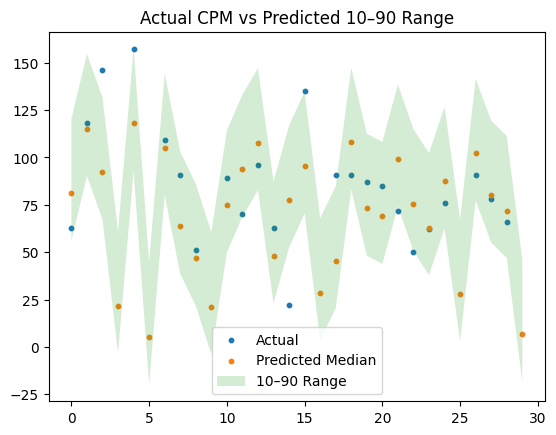

In [214]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    range(len(val_preds)),
    val_preds["actual_cpm"],
    label="Actual",
    s=10
)
plt.scatter(
    range(len(val_preds)),
    val_preds["cpm_p50"],
    label="Predicted Median",
    s=10
)
plt.fill_between(
    range(len(val_preds)),
    val_preds["cpm_p10_cal"],
val_preds["cpm_p90_cal"],
    alpha=0.2,
    label="10–90 Range"
)
plt.legend()
plt.title("Actual CPM vs Predicted 10–90 Range")
plt.show()

Conformal Changes

In [215]:
actual = val_preds["actual_cpm"].values
low = val_preds["cpm_p10_cal"].values
high = val_preds["cpm_p90_cal"].values

# Nonconformity scores
errors = np.maximum(
    low - actual,
    actual - high
)

# Remove negatives and NaNs
errors = errors[errors > 0]
errors = errors[~np.isnan(errors)]
alpha = 0.1
q_hat = np.quantile(errors, 1 - alpha)

q_hat
val_preds["cpm_low_conf"] = val_preds["cpm_p10_cal"] - q_hat
val_preds["cpm_high_conf"] = val_preds["cpm_p90_cal"] + q_hat
coverage_conf = (
    (val_preds["actual_cpm"].values >= val_preds["cpm_low_conf"].values) &
    (val_preds["actual_cpm"].values <= val_preds["cpm_high_conf"].values)
).mean()

coverage_conf


np.float64(0.7666666666666667)

In [ ]:
import joblib

model_bundle = {
    "model_p10": model_p10,
    "model_p50": model_p50,
    "model_p90": model_p90,
    "q_hat": q_hat,  
    "feature_columns": X.columns.tolist(),
    "alpha": 0.1,
    "coverage_val": coverage_conf
}

joblib.dump(model_bundle, "cpm_quantile_model_conformal_v1.pkl")

['cpm_quantile_model_conformal_v1.pkl']